In [1]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio
import matplotlib.pylab as plt
import matplotlib.colors as colors
import torch
from torch.utils.data import DataLoader

import os
import time                   
import sys
import argparse 

sys.path.insert(0, '../code') 
from network import UNet
from model_loader_func import load_UNet
from plotting_func import plot_many_denoised, plot_single_im
from quality_metrics_func import calc_psnr, im_set_corr
from linear_approx import calc_jacobian, traj_projections
from inverse_tasks_func import synthesis
from algorithm_inv_prob import univ_inv_sol
from dataloader_func import add_noise_torch

%matplotlib inline

/gpfslocalsup/pub/anaconda-py3/2022.05/envs/pytorch-gpu-1.13.0+py3.10.8/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import matplotlib as mpl

In [3]:
print(torch.__version__)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

1.13.0


device(type='cuda')

In [4]:
def show_im_set(dataset , N=None , im_size=3,vmin=None, vmax=None, label=None, 
                colorbar=False,n_columns=7, sub_labels=None, colormap='gray',
               norm=None, font_size=30, label_size=None):
    if N is None:
        N = dataset.shape[0]
    device = dataset.device
    if device.type == 'cuda':
        dataset = dataset.cpu()

    if dataset.shape[1] != 1:
        dataset = dataset.permute(0,2,3,1)


    n_rows = int(N/n_columns)
    if N%n_columns != 0:
        n_rows = n_rows+1

    f, axs = plt.subplots(n_rows, n_columns, figsize = (im_size * n_columns , im_size * n_rows))
    axs = axs.ravel()
    if label is not None:
        f.suptitle( label , fontsize = label_size)
    for i in range(N ):
        if dataset.shape[1] == 1:
            fig = axs[i].imshow(dataset[i,0], colormap,norm=norm, vmin=vmin, vmax = vmax)
        else:
            fig = axs[i].imshow(rescale_image_range(dataset[i],1), colormap,norm=norm)

        if colorbar:
            plt.colorbar(fig, ax=axs[i], fraction=.05)
        if sub_labels is not None:
            axs[i].set_title( str(sub_labels[i]), fontsize = font_size)
#        else:
#            axs[i].set_title(str(i))
    for i in range(len(axs)):
        axs[i].axis('off')
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
    dataset = dataset.to(device)
 

# Load denoisers

In [5]:
## Load pretraiend denoisers 

denoisers_face = {}
# denoisers in group A are trained on one partision of the data which is non-overlapping with partision B
groups = ['A', 'B'] 
swap = False
training_data_name = 'sdss'

Ns = [1,10,100,1000, 10000,100000] #size of the dataset 

for group in groups: 
    print('loading group ' , group )
    denoisers_face[group] = {}
    if group == 'B': 
        swap = True
    for N in Ns:       
        start_time_total = time.time()        
        try: 
            denoisers_face[group][N] = load_UNet(
                           base_path = '../denoisers/UNet',
                           training_data_name= training_data_name, 
                           training_noise='0to255',
                           RF=90,
                           set_size=N, 
                           swap=swap);
        except FileNotFoundError: 
            pass 
        print("--- %s seconds ---" % (round(time.time() - start_time_total)))


loading group  A
--- 3 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
loading group  B
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---
--- 0 seconds ---


In [6]:
Ns = list(denoisers_face['A'].keys())
print(Ns)

[1, 10, 100, 1000, 10000, 100000]


# Load DataSet

In [7]:
train_face ={}
test_face = {}
train_face['A'] = {}
train_face['B'] ={}
test_face['B'] = {}
test_face['A'] = {}

data = torch.load('../../datasets/sdss_train_no_repeats_64x64.pt')
K = data.shape[2]
print(data.shape)
for N in Ns:
    train_face['A'][N] = data[0:N]
    test_face['A'][N] = data[-N::]
    train_face['B'][N] = data[-N::]
    test_face['B'][N] = data[0:N]   

torch.Size([250000, 1, 64, 64])


# Compare samples from two sets of denoisers 

In [8]:
#Generate many samples from a pair of denoisers trained on N images 
N = 100_000
n_samples = 20
shift = 0
seeds = range(shift,shift+n_samples)
freq =0 # 0 means no print

all_samples = {}
all_interm_Ys = {}
all_sigmas={}
all_means = {}

start_time_total = time.time()
synth = synthesis()

for group in groups: 
    print('------------ group: ', group)
  
    all_samples[group] = torch.zeros(n_samples, 1, K,K).to(device)
    all_interm_Ys[group] = []
    all_sigmas[group] = []
    all_means[group] = [] 
    
    for n in range(n_samples): 
        if freq: print('--------- N : ', N)        
        torch.manual_seed(seeds[n])
        sample, interm_Ys,sigmas, means =univ_inv_sol(denoisers_face[group][N], 
                                                             x_c= torch.zeros(1,K,K).cuda(),
                                                             task=synth,
                                                             device=device,
                                                             sig_0=1, 
                                                             sig_L=.1, 
                                                             h0=.01 , 
                                                             beta=.1 , 
                                                             freq=freq,
                                                             seed = seeds[n], 
                                                             init_im = train_face[group][N].mean(dim=0).cuda() + torch.randn(1,K,K, device = device), 
                                                             init_noise_mean=0,
                                                             max_T=10000, 
                                                             fixed_h=False)
        all_samples[group][n, 0] = sample.detach()
        all_interm_Ys[group].append(interm_Ys)
        all_sigmas[group].append(sigmas)
        all_means[group].append(means)
        
print("--- %s seconds ---" % (time.time() - start_time_total))

------------ group:  A
------------ group:  B
--- 18.3158278465271 seconds ---


# pairs cosine similarities 

In [41]:
SMALL_SIZE = 32
MEDIUM_SIZE = 34
BIGGER_SIZE = 36

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

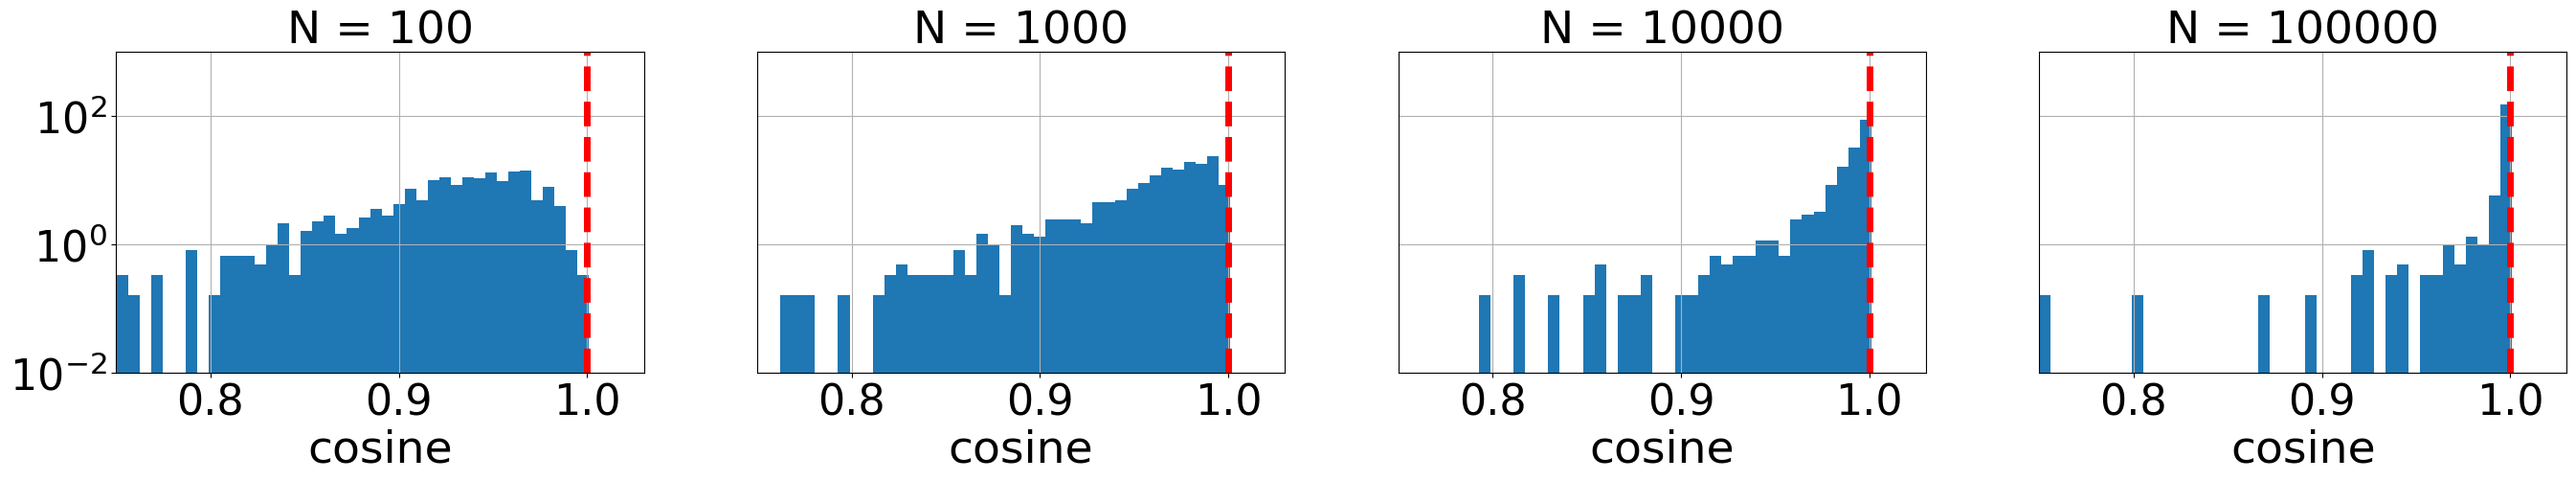

In [46]:

f, ax = plt.subplots(1,4, figsize = (7*4,5) , sharey = True)
plt.tight_layout()
i = 0
for N in [100,1000,10000,100_000]: 
    
    many_samples_faces = torch.load('../results/img_align_sdss_64x64/UNet_many_samples_'+str(N) +'.pt',
                                   map_location=torch.device('cpu'))
    sims = im_set_corr ( (many_samples_faces['A']) , (many_samples_faces['B']) ).diag()
    bins = np.linspace(0.75,1.05 ,50)

    ax[i].hist(sims.cpu().flatten(), bins = bins, alpha = 1, density=True)

    if i==0:
        ax[i].tick_params(bottom=True,left=True,labelleft=True,labelbottom=True)
    else:
        ax[i].tick_params(bottom=True,left=False,labelleft=False,labelbottom=True)

    ax[i].set_xlim(0.75,1.03)
    ax[i].set_ylim(1e-2,1e3)
    ax[i].set_title('N = '+str(N));
    ax[i].axvline(x=1.0,c='r',lw=5,ls="--")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("cosine")
    ax[i].grid()
    i += 1 

plt.savefig("diffusion-cosine-AB.pdf")

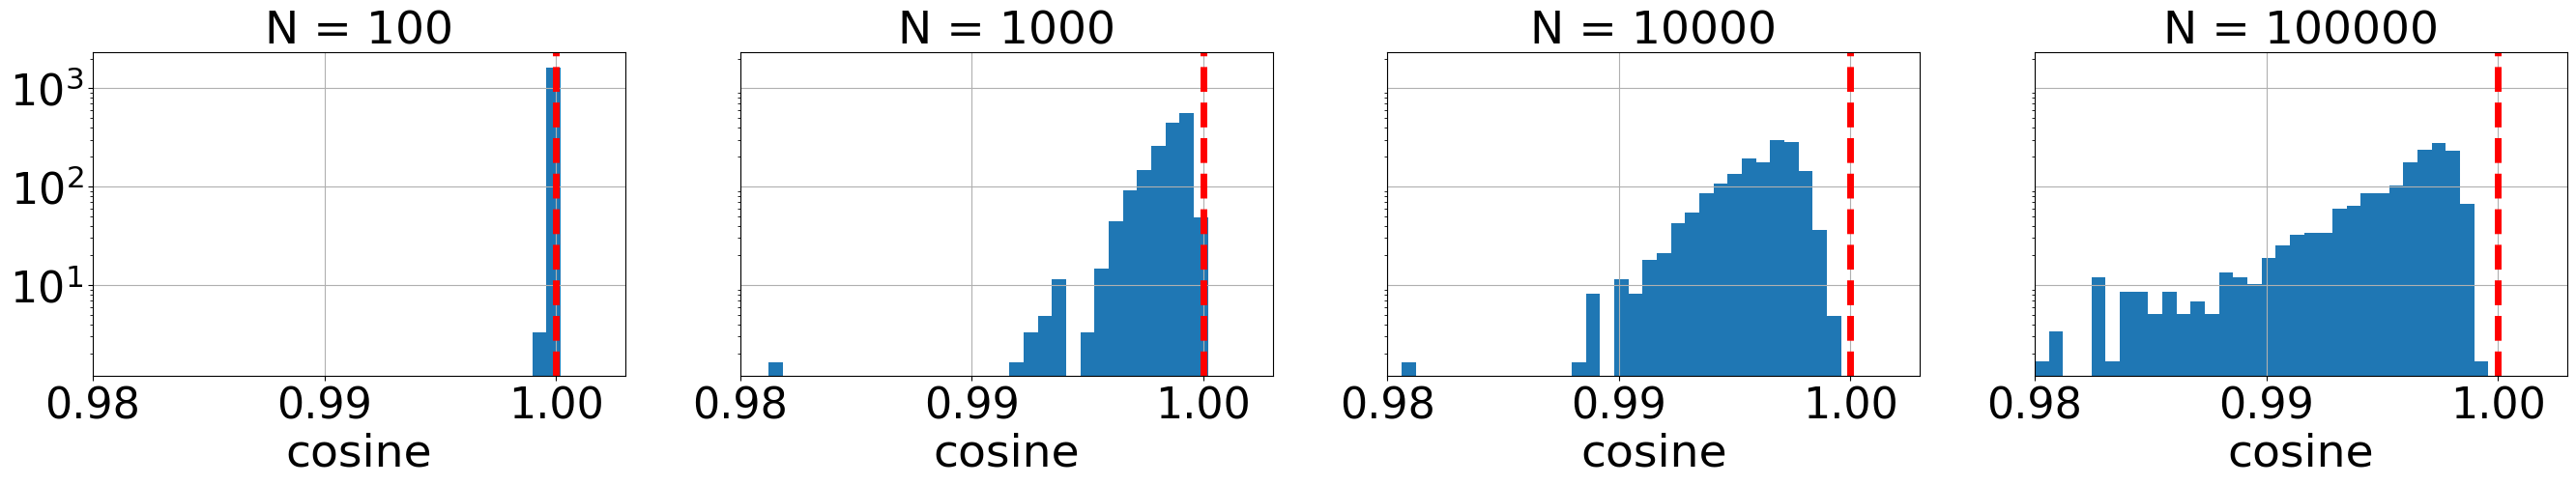

In [47]:
f, ax = plt.subplots(1,4, figsize = (7*4,5) , sharey = True)
plt.tight_layout()
i = 0
for N in [100,1_000,10_000,100_000]: 
    
    many_samples_faces = torch.load('../results/img_align_sdss_64x64/UNet_many_samples_'+str(N) +'.pt',
                                   map_location=torch.device('cpu'))
    bins = np.linspace(0.98,1.01,50)

    # compute correlations between generated samples and closest images from the train set 
    corrs = im_set_corr((many_samples_faces['A']).to(device), (train_face['A'][N].to(device)) )
    values, indices = corrs.max(dim = 1)
    ax[i].hist(values.cpu() , bins = bins, alpha = 1.0, density=True)

    if i==0:
        ax[i].tick_params(bottom=True,left=True,labelleft=True,labelbottom=True)
    else:
        ax[i].tick_params(bottom=True,left=False,labelleft=False,labelbottom=True)

    ax[i].set_xlim(0.98,1.003)
    ax[i].set_title('N = '+str(N));
    ax[i].set_yscale("log")
    ax[i].axvline(x=1.0,c='r',lw=5,ls="--")
    ax[i].set_xlabel("cosine")
    ax[i].grid()
    i += 1 
plt.savefig("diffusion-cosine-ATrain.pdf")